In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI
from langchain_classic import hub

rag_prompt = hub.pull('rlm/rag-prompt')
llm = ChatOpenAI(model="gpt-4o")
small_llm = ChatOpenAI(model="gpt-4o-mini")

c:\Users\JJH\anaconda3\envs\langchain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str 
    context: list
    answer: str
   
graph_builder = StateGraph(AgentState)

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['income_tax', 'llm', 'real_estate_tax'] = Field(
        description="The target for the query to answer"
    )

router_prompt_prompt = """
You are an expert at routing a user's question to 'income_tax', 'llm', or 'real_estate_tax'.
'income_tax' contains information about income tax up to April 2026.
'real_estate_tax' contains information about real estate tax up to April 2026.
if you think the question is not related to either 'income_tax' or 'real_estate_tax';
you can route it to 'llm'. """

router_prompt = ChatPromptTemplate.from_messages([
    ('system', 'router_prompt_prompt'),
    ('user', '{query}')
])

structured_router_llm = small_llm.with_structured_output(Route)

def router(state: AgentState):
    query = state['query']
    router_chain = router_prompt | structured_router_llm
    route = router_chain.invoke({'query': query})
    print(f'router route == {route}')
    print(f'router.target == {route.target}')
    return route.target

In [ ]:
from langchain_core.output_parsers import StrOutputParser

def call_llm(state: AgentState):
    query = state['query']
    llm_chain = small_llm | StrOutputParser()
    llm_answer = llm_chain.invoke(query)
    return {'answer': llm_answer}

In [6]:
from income_tax_graph import graph as income_tax_agent
from real_estate_graph import graph as real_estate_agent

graph_builder.add_node('income_tax', income_tax_agent)
graph_builder.add_node('real_estate_tax', real_estate_agent)
graph_builder.add_node('llm', call_llm)

c:\Users\JJH\Desktop\langchain-basics\langgraph\real_estate_graph.py:101: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search_tool = TavilySearchResults(


{'context': [{'title': '세금 아직 한발 남았다? ‘공정시장가액비율’ 대통령에 달렸다 [부동산360]', 'url': 'https://v.daum.net/v/20260322160153201', 'content': '이 같은 발언의 배경에는 공정시장가액비율 조정 가능성이 깔려 있다는 해석이 나온다. 세율을 직접 조정하지 않더라도 공정시장가액비율을 조정하면 증세가 가능하기 떄문이다. 공정시장가액비율은 재산세와 종합부동산세의 과세표준을 정할 때 공시가격에 곱하는 비율을 의미한다. 해당 제도는 지난 2009년 이명박 정부 당시 감세와 종부세 완화를 목적으로 도입됐다.\n\n재산세 공정시장가액비율은 2009년 도입 뒤 주택 60%에서 2017년 100%까지 단계적으로 올랐고, 2022년부터는 1주택자에 한해 세부담 완화를 위해 다시 45%, 이후 주택가격 별로 3억 이하 43%, 3억 초과 6억 이하 44%, 6억 초과 45% 특례가 적용돼 왔다. 2026년 현행 시행령상 기본비율은 주택 60%, 토지·건축물 70%다.\n\n종부세 기준 공시가격가액비율은 2018년까지 80%를 유지해왔으나, 문재인 정부 들어 과세 강화 방침에 따라 매년 5%포인트씩 상향되어 2021년 95%까지 인상된 바 있다. 이후 윤석열 정부는 2022년 해당 비율을 60%로 대폭 하향 조정해 현재까지 유지하고 있는 상태다.\n\n공정시장가액비율 개편이 예측되는 이유는 조정 방식이 간단해서다. 현행 체제상 공정시장가액비율은 법률이 정한 범위 내에서 정부가 ‘대통령령’을 통해 탄력적으로 조정할 수 있다. 다만 소관 부처는 세목에 따라 나뉜다. 지방세인 재산세는 행정안전부가 담당하며, 국세인 종부세는 기획재정부 소관이다. 별다른 법 개정이 필요하지 않아 공정시장가액비율 조정은 부동산 시장 집값 안정화를 위한 가장 손쉬운 방법으로 꼽힌다. [...] ![보유세가 상한까지 오를 것으로 예상되는 서울 서초구 반포동 ‘래미안 원베일리’ 아파트의 모습. [헤럴드경제DB]](\n\n![보유세가

In [7]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'income_tax': 'income_tax',
        'real_estate_tax': 'real_estate_tax',
        'llm': 'llm'
    }
)

graph_builder.add_edge('income_tax', END)
graph_builder.add_edge('real_estate_tax', END)
graph_builder.add_edge('llm', END)


In [8]:
graph = graph_builder.compile()

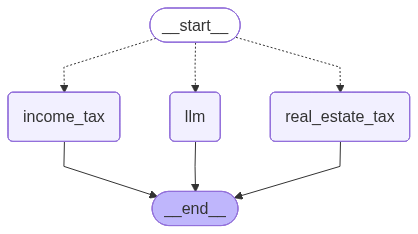

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
initial_state = {'query':'소득세란 무엇인가요?'}
graph.invoke(initial_state)

router route == target='income_tax'
router.target == income_tax


{'query': '소득세란 무엇인가요?',
 'context': [Document(id='1a3f3af4-0029-4ff5-84fb-6cab853a3730', metadata={'source': './documents/income_tax.txt'}, page_content='①조 세특례제한법, 또는 이 법 제12조에 따른 과세제외 소득  \n대통령령으로 정하는 임금소득(이하 “임금소득”이라 한다)과 근로소득  \n\n제12조제2항의 세호에 따라 원천징수하는 이자소득 및 배당소득과 제16조제1항제10호에 따른 직장공제회초 관련소득  \n\n\n법인으로 보는 단체 외의 단체 중 소득을 구성함에 배분하지 아니하는 단체로서 단체를 표기하는 금융거래를 하는 단체가 “금융신용기관” 및 비임금소득에 관한 법령이 제20조제1항 목의 이후에 해당하는 금융사업을 하는 단체(이하 “금융회사”等이란)로부터 받은 이자소득 및 배당소득  \n\n\n①조 세특례제한법에 따른 보통계소득  \n\n\n제30조부터 제35조까지의 규정 외의 이자소득과 배당소득(제17조제1항제8호에 따른 배당소득을 제외한다)으로서 그 소득의 합계액이 2천만원(이하 “이자소득의 종합세액기준금액”이라 한다) 이하인 경우 제17조에 따른 원천징수된 소득  \n\n\n해당 과세기간에 배당행정을 정하는 총수입금액의 합계액이 2천만원 이하인 자의 주택임대소득(이하 “분리과세 주택임대소득”이라 한다). 이 경우 주택임대소득이 산정 등에 필요한 대책행령으로 정한다.  \n\n\n다음 각 목 외의 기타소득(이하 “분리과세 기타소득”이라 한다)  \n\n\n가. 제21조제1항제3호 제4항, 제19조, 제20조제1항, 제22조제2항, 제26조 및 제26조의2 및 제 127조에 따라 원천징수(제21조제19항에 의하여 원천징수되지 아니하는 경우를 포함한다) 소득. 다만, 해당 소득이 있는 거주자가 종합소득과세표준을 계산해 고소득을 합산하는 경우 그 소득은 분리과세로 세액계산에 제외한다.  \n나. 제21조제19항제2조 및 같은 조 

In [13]:
initial_state = {
    'query': '집 15억은 세금을 얼마나 내나요?'
}

graph.invoke(initial_state)

router route == target='real_estate_tax'
router.target == real_estate_tax
{'context': [{'title': '세금 아직 한발 남았다? ‘공정시장가액비율’ 대통령에 달렸다 [부동산360]', 'url': 'https://v.daum.net/v/20260322160153201', 'content': '이 같은 발언의 배경에는 공정시장가액비율 조정 가능성이 깔려 있다는 해석이 나온다. 세율을 직접 조정하지 않더라도 공정시장가액비율을 조정하면 증세가 가능하기 떄문이다. 공정시장가액비율은 재산세와 종합부동산세의 과세표준을 정할 때 공시가격에 곱하는 비율을 의미한다. 해당 제도는 지난 2009년 이명박 정부 당시 감세와 종부세 완화를 목적으로 도입됐다.\n\n재산세 공정시장가액비율은 2009년 도입 뒤 주택 60%에서 2017년 100%까지 단계적으로 올랐고, 2022년부터는 1주택자에 한해 세부담 완화를 위해 다시 45%, 이후 주택가격 별로 3억 이하 43%, 3억 초과 6억 이하 44%, 6억 초과 45% 특례가 적용돼 왔다. 2026년 현행 시행령상 기본비율은 주택 60%, 토지·건축물 70%다.\n\n종부세 기준 공시가격가액비율은 2018년까지 80%를 유지해왔으나, 문재인 정부 들어 과세 강화 방침에 따라 매년 5%포인트씩 상향되어 2021년 95%까지 인상된 바 있다. 이후 윤석열 정부는 2022년 해당 비율을 60%로 대폭 하향 조정해 현재까지 유지하고 있는 상태다.\n\n공정시장가액비율 개편이 예측되는 이유는 조정 방식이 간단해서다. 현행 체제상 공정시장가액비율은 법률이 정한 범위 내에서 정부가 ‘대통령령’을 통해 탄력적으로 조정할 수 있다. 다만 소관 부처는 세목에 따라 나뉜다. 지방세인 재산세는 행정안전부가 담당하며, 국세인 종부세는 기획재정부 소관이다. 별다른 법 개정이 필요하지 않아 공정시장가액비율 조정은 부동산 시장 집값 안정화를 위한 가장 손쉬운 방법으로 꼽힌다. [...] ![

{'query': '집 15억은 세금을 얼마나 내나요?',
 'answer': '주어진 정보에 따르면, 1세대 1주택자가 공시가격 15억 원의 주택을 소유하고 있을 때의 과세표준을 계산해보면 다음과 같습니다:\n\n1. 공시가격: 15억 원\n2. 공정시장가액비율: 45%\n3. 기본공제액: 12억 원\n\n과세표준 = (공시가격 × 공정시장가액비율) - 기본공제액\n과세표준 = (15억 원 × 0.45) - 12억 원\n과세표준 = 6.75억 원 - 12억 원\n과세표준 = -5.25억 원\n\n과세표준이 음수인 경우, 종합부동산세를 납부할 필요가 없습니다. 따라서, 1세대 1주택자가 공시가격이 15억 원인 주택을 소유한 경우에는 종합부동산세를 내지 않아도 됩니다.'}

In [14]:
initial_state = {'query':'떡볶이는 어디가 맛있나요?'}
graph.invoke(initial_state)

router route == target='llm'
router.target == llm


ValueError: Invalid input type <class 'dict'>. Must be a PromptValue, str, or list of BaseMessages.